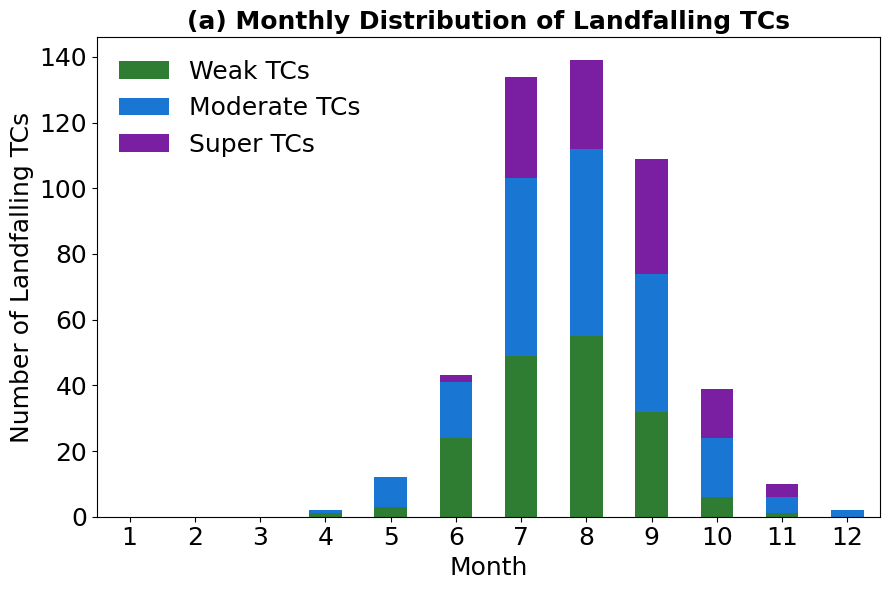

Data statistics:
Total number of landfalling TCs: 490
Counts by month and category:
category_name  Weak TCs  Moderate TCs  Super TCs
month                                           
1                     0             0          0
2                     0             0          0
3                     0             0          0
4                     1             1          0
5                     3             9          0
6                    24            17          2
7                    49            54         31
8                    55            57         27
9                    32            42         35
10                    6            18         15
11                    1             5          4
12                    0             2          0

Total count by category:
category_name
Weak TCs        171
Moderate TCs    205
Super TCs       114
dtype: int64


In [2]:
# %%
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Read data
file_path = "./typhoon_output/landfall_typhoons_info.csv"
df = pd.read_csv(file_path)

# 2. Parse landfall time
df['landfall_time'] = pd.to_datetime(df['landfall_time'], errors='coerce')
# Drop invalid times
df = df.dropna(subset=['landfall_time'])
# Extract year and month
df['year'] = df['landfall_time'].dt.year
df['month'] = df['landfall_time'].dt.month

# 3. Filter 1960-2024
df = df[(df['year'] >= 1960) & (df['year'] <= 2024)]

# 4. Define typhoon category mapping
category_map = {1: 'Weak TCs', 2: 'Moderate TCs', 3: 'Super TCs'}
color_map = {'Weak TCs': '#2E7D32', 'Moderate TCs': '#1976D2', 'Super TCs': '#7B1FA2'}

# Check if max_wind_category has other values; if so, handle or filter
valid_cats = [1,2,3]
df = df[df['max_wind_category'].isin(valid_cats)]

# Create category name column
df['category_name'] = df['max_wind_category'].map(category_map)

# 5. Group and count: by month and category
counts = df.groupby(['month', 'category_name']).size().unstack(fill_value=0)

# Ensure all months 1-12 are present
months = range(1,13)
counts = counts.reindex(months, fill_value=0)

# 6. Plot
fig, ax = plt.subplots(figsize=(9,6))

# Stacked bar chart
categories = ['Weak TCs', 'Moderate TCs', 'Super TCs']
colors = [color_map[cat] for cat in categories]
counts_ordered = counts[categories]

counts_ordered.plot(kind='bar', stacked=True, ax=ax, color=colors)

# Axis labels
ax.set_xlabel('Month', fontsize=18)
ax.set_ylabel('Number of Landfalling TCs', fontsize=18)

ax.set_title('(a) Monthly Distribution of Landfalling TCs', fontsize=18, fontweight='bold')
ax.tick_params(axis='both', labelsize=18)
ax.legend(['Weak TCs', 'Moderate TCs', 'Super TCs'], fontsize=18, frameon=False, loc='upper left')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('1a.png', dpi=600, bbox_inches='tight')
plt.show()

# 7. Output statistics
print("Data statistics:")
print(f"Total number of landfalling TCs: {len(df)}")
print("Counts by month and category:")
print(counts_ordered)
print("\nTotal count by category:")
print(counts_ordered.sum())